In [1]:
pip install idx2numpy

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import idx2numpy
import matplotlib.pyplot as plt
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neural_network import MLPClassifier

In [2]:
x_train = idx2numpy.convert_from_file('../MNIST/train-images.idx3-ubyte')
y_train = idx2numpy.convert_from_file('../MNIST/train-labels.idx1-ubyte')

x_test = idx2numpy.convert_from_file('../MNIST/t10k-images.idx3-ubyte')
y_test = idx2numpy.convert_from_file('../MNIST/t10k-labels.idx1-ubyte')

In [3]:
x_train[0] # this is how a 28 X 28 image is represented in matrix

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

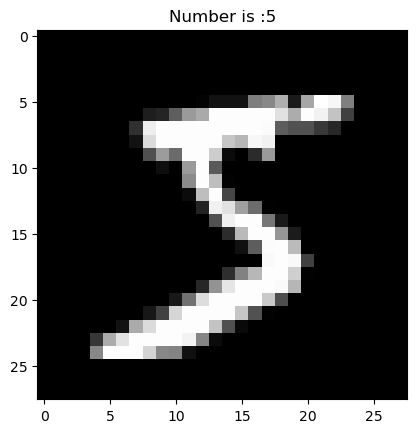

In [4]:
plt.imshow(x_train[0],cmap="grey")
plt.title(f"Number is :{y_train[0]}")
plt.show()

In [5]:
flat_array = np.array(x_train[0].flatten())

In [6]:
flat_array[269]

np.uint8(154)

TRAINING LOGISTIC REGRESSION
--

In [7]:
pipe = Pipeline([
    ('model',LogisticRegression(
        random_state = 42,
        class_weight = 'balanced',
        max_iter = 1000,
        multi_class = "multinomial"
    
    ))
])

---
<i>RESHAPING IS IMPORTANT BECAUSE THE X_TRAIN IS IN 3 DIMESION BUT LOGISTIC REGRESSION NEEDS 2D INPUT</i>

---

In [8]:
x_train = x_train.reshape(60000,784)
x_test = x_test.reshape(10000,784)

----
SCALING FEATURE TO OPTIMIZE THE GRADIENT AND LOGISTIC REGRESSION

---

In [9]:

x_train = x_train/255.0 #this is to scale the features
x_test = x_test/255.0

In [10]:
pipe.fit(x_train,y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Pipeline(steps=[('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    multi_class='multinomial',
                                    random_state=42))])

In [11]:
y_pred = pipe.predict(x_test)

In [12]:
precisionScore = precision_score(y_test,y_pred,average=None)
print(precisionScore)

[0.95318725 0.9643788  0.92729084 0.90810277 0.93699187 0.89066059
 0.94300518 0.93669634 0.88090349 0.91150442]


In [13]:
recall = recall_score(y_test,y_pred,average=None)
print(recall)

[0.97653061 0.97797357 0.90213178 0.90990099 0.9389002  0.87668161
 0.94989562 0.92120623 0.88090349 0.91873142]


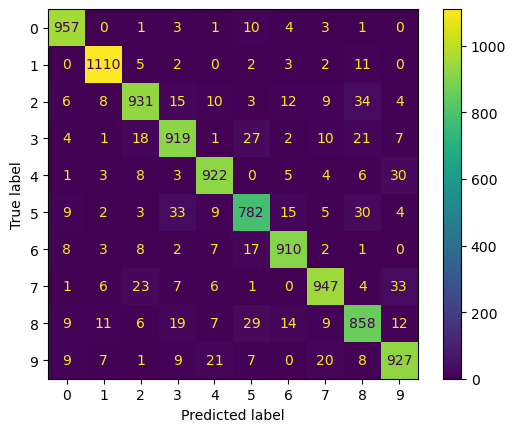

In [14]:
confusionMatrix = confusion_matrix(y_test,y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=confusionMatrix)
display.plot()
plt.show()